## 1. Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import math

## 2. Dataset

In [3]:
data_mnist = tf.keras.datasets.mnist
(train_img, label_train), (test_img, label_test) = data_mnist.load_data()

## 3. Pré-processing


In [4]:
# Normalização
train_img = train_img / 255.0
test_img = test_img / 255.0

In [5]:
# Codificação
label_train_one_hot = tf.one_hot(label_train, 10)
label_test_one_hot = tf.one_hot(label_test, 10)

I0000 00:00:1787610277.016150   14003 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5743 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


### 3.1. Exemples

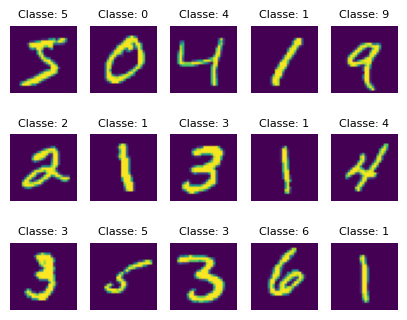

In [6]:
plt.figure(figsize=(5,4))
for index in range(15):
    plt.subplot(3, 5, index + 1)
    plt.imshow(train_img[index])
    plt.title(f"Classe: {tf.argmax(label_train_one_hot[index])}", fontsize=8)
    plt.axis("off")
plt.show()

## 4. MLP Net

In [ ]:
model_mlp = tf.keras.models.Sequential(
    [
        tf.keras.layers.Input(shape=(28,28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ]
)
model_mlp.summary()

### 4.1. Train net

In [ ]:
opt = tf.optimizers.Adam(learning_rate=0.01)

In [ ]:
model_mlp.compile(optimizer=opt, loss="mse", metrics=["mse"])

train_history = model_mlp.fit(
    train_img,
    label_train_one_hot,
    epochs = 5,
    validation_split = 0.1
)

### 4.2. Train and validation error chart 

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(train_history.history["loss"])
plt.plot(train_history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])

### 4.3. Save trained model

In [ ]:
model_mlp.save("meu_modelo_mnist.keras")

## 5. Inference Test with the train model

In [ ]:
load_model = tf.keras.models.load_model("meu_modelo_mnist.keras")

# selecionar uma amostra do conjunto de teste
indice_amostra = 0
amostra = test_img[indice_amostra]
amostra_batch = np.expand_dims(amostra, axis=0)

# Realizar predição
predict = load_model.predict(amostra_batch)
predict_class = np.argmax(predict)
real_class = label_test[indice_amostra]
print(f"Predição: {predict_class} | Real: {real_class}")

## 6. Exercise

In [47]:
model_mlp = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

pesos_iniciais = model_mlp.get_weights()

def train(opt):
    model.set_weights(pesos_iniciais)
    
    model.compile(optimizer=opt, loss="mse", metrics=["mse"])

    train_history = model.fit(
        train_img,
        label_train_one_hot,
        epochs=5,
        validation_split=0.1
    )
    
    return train_history

Epoch 1/5


I0000 00:00:1787614816.618209   15248 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1812287__.10


1665/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0197 - mse: 0.0197

I0000 00:00:1787614820.421274   15250 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1812287__.10


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0142 - mse: 0.0142 - val_loss: 0.0092 - val_mse: 0.0092
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0115 - mse: 0.0115 - val_loss: 0.0119 - val_mse: 0.0119
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0118 - mse: 0.0118 - val_loss: 0.0099 - val_mse: 0.0099
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0114 - mse: 0.0114 - val_loss: 0.0081 - val_mse: 0.0081
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0112 - mse: 0.0112 - val_loss: 0.0098 - val_mse: 0.0098


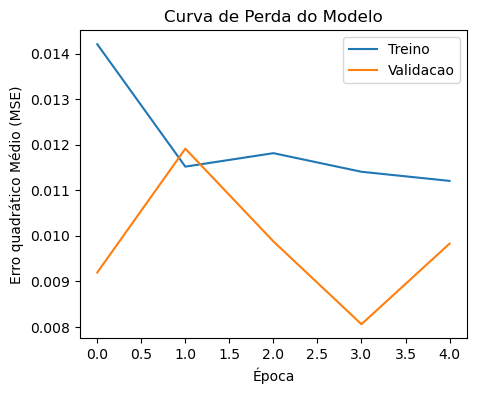

In [48]:
opt = tf.optimizers.Adam(learning_rate=0.01)
#opt = tf.optimizers.SGD(learning_rate=0.01)
#opt = tf.optimizers.RMSprop(learning_rate=0.01)
#opt = tf.optimizers.AdamW(learning_rate=0.01)
#opt = tf.optimizers.Adadelta(learning_rate=0.01)
#opt = tf.optimizers.Adagrad(learning_rate=0.01)
#opt = tf.optimizers.Adamax(learning_rate=0.01)
#opt = tf.optimizers.Adafactor(learning_rate=0.01)
#opt = tf.optimizers.Nadam(learning_rate=0.01)
#opt= tf.optimizers.Ftrl(learning_rate=0.01)
#opt = tf.optimizers.Lion(learning_rate=0.01)
#opt = tf.optimizers.Lamb(learning_rate=0.01)
#opt = tf.optimizers.Muon(learning_rate=0.01)  
    
train_history = train(opt)

plt.figure(figsize=(5, 4))
plt.plot(train_history.history["loss"])
plt.plot(train_history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])

plt.savefig("test.png")
plt.show()